In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.style import set_plot_style, COLORS, fa
from src.utils.plot_utils import save_figure
from src.utils.statistics import interpret_cohens_d

set_plot_style()

In [ ]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

In [3]:
df[["building_size", "construction_year"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   building_size      980394 non-null  float64
 1   construction_year  815828 non-null  str    
dtypes: float64(1), str(1)
memory usage: 15.3 MB


In [4]:
df[["building_size", "construction_year"]].isna().sum()

building_size         19606
construction_year    184172
dtype: int64

In [41]:
house = df[["building_size", "construction_year"]].copy()
house

,building_size,construction_year
0,500.0,NaN
1,60.0,۱۳۸۴
2,132.0,۱۴۰۱
3,90.0,۱۴۰۰
4,115.0,۱۴۰۳
...,...,...
999995,180.0,۱۴۰۳
999996,110.0,۱۴۰۳
999997,200.0,قبل از ۱۳۷۰
999998,70.0,NaN


In [42]:
import re


def normalize_year(value):
    if pd.isna(value):
        return None

    value = str(value)

    value = value.translate(str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789"))

    match = re.search(r"\d{4}", value)

    if match:
        return int(match.group())

    return None

In [43]:
house["construction_year"] = house["construction_year"].apply(normalize_year)
house["construction_year"]

0            NaN
1         1384.0
2         1401.0
3         1400.0
4         1403.0
           ...  
999995    1403.0
999996    1403.0
999997    1370.0
999998       NaN
999999    1382.0
Name: construction_year, Length: 1000000, dtype: float64

In [44]:
house = house.dropna(subset=["building_size", "construction_year"])
house

,building_size,construction_year
1,60.0,1384.0
2,132.0,1401.0
3,90.0,1400.0
4,115.0,1403.0
5,100.0,1389.0
...,...,...
999993,50.0,1386.0
999995,180.0,1403.0
999996,110.0,1403.0
999997,200.0,1370.0


In [45]:
house["construction_year"].value_counts().head(20)

construction_year
1403.0    116259
1390.0     59139
1402.0     58424
1400.0     53674
1395.0     53029
1398.0     38207
1397.0     36325
1396.0     35487
1401.0     35328
1385.0     34065
1399.0     29594
1393.0     29094
1392.0     26130
1394.0     26110
1388.0     24268
1380.0     23480
1370.0     20637
1389.0     16755
1391.0     16316
1387.0     14136
Name: count, dtype: int64

In [46]:
house["house_type"] = np.where(house["construction_year"] < 1396, "Old", "New")

In [47]:
summary = (
    house.groupby("house_type")["building_size"]
    .agg(Count="count", Mean="mean", Median="median", Std="std", Min="min", Max="max")
    .round(2)
)
summary

,Count,Mean,Median,Std,Min,Max
house_type,,,,,,
New,403298,3278.33,105.0,120228.69,1.0,10000000.0
Old,412528,2758.67,85.0,111650.79,1.0,10000000.0


In [48]:
house["house_type"].value_counts()

house_type
Old    412528
New    403298
Name: count, dtype: int64

In [49]:
house["building_size"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]).round(2)

count      815826.00
mean         3015.56
std        115970.76
min             1.00
90%           200.00
95%           300.00
99%          3200.00
99.5%       20000.00
99.9%      450000.00
max      10000000.00
Name: building_size, dtype: float64

In [50]:
house.nlargest(20, "building_size")[["building_size", "construction_year"]]

,building_size,construction_year
3207,10000000.0,1399.0
27686,10000000.0,1383.0
64230,10000000.0,1397.0
115504,10000000.0,1401.0
147643,10000000.0,1396.0
167125,10000000.0,1379.0
170378,10000000.0,1392.0
173270,10000000.0,1403.0
174631,10000000.0,1399.0
176115,10000000.0,1403.0


In [51]:
upper_limit = house["building_size"].quantile(0.995)

In [52]:
print("Before:", len(house))

house = house[house["building_size"] <= upper_limit]

print("After :", len(house))

Before: 815826
After : 811867


In [53]:
house["building_size"].describe().round(2)

count    811867.00
mean        172.10
std         718.99
min           1.00
25%          70.00
50%          95.00
75%         135.00
max       20000.00
Name: building_size, dtype: float64

<p dir="rtl">

با بررسی توزیع متراژ مشخص شد که مقادیری مانند ۱۰,۰۰۰,۰۰۰ متر مربع در داده وجود دارد که به احتمال زیاد ناشی از خطای ثبت داده هستند. برای جلوگیری از تأثیر این مقادیر بر میانگین و آزمون‌های آماری، مقادیر بالاتر از صدک 99.5 حذف شدند.

</p>

Figure saved -> D:\Quera\Exercises\project01\divar-real-estate-ml\reports\figures\old_vs_new_house_size.png


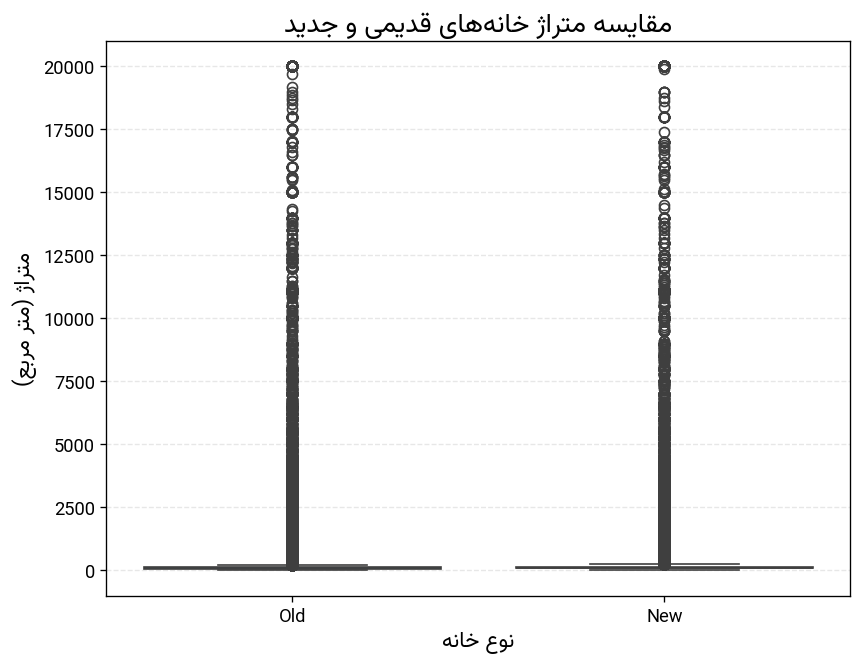

In [56]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=house, x="house_type", y="building_size")

plt.title(fa("مقایسه متراژ خانه‌های قدیمی و جدید"))

plt.xlabel(fa("نوع خانه"))

plt.ylabel(fa("متراژ (متر مربع)"))

save_figure("old_vs_new_house_size")

plt.show()

In [59]:
from scipy.stats import levene
from scipy.stats import ttest_ind

In [58]:
old = house.loc[house["house_type"] == "Old", "building_size"]

new = house.loc[house["house_type"] == "New", "building_size"]

stat, p = levene(old, new)

print(stat)
print(p)

33.18400750244928
8.386734474331011e-09


In [61]:
t_stat, p_two = ttest_ind(old, new, equal_var=False)

p_one = 1 - (p_two / 2)

print("t =", t_stat)
print("one-sided p =", p_one)

t = -14.506979509972382
one-sided p = 1.0


<p dir="rtl">

آزمون Levene نشان داد که واریانس متراژ خانه‌های قدیمی و جدید برابر نیست (p < 0.05)، بنابراین از آزمون t ولش (Welch's t-test) استفاده شد. نتیجه آزمون نشان داد که مقدار آماره t منفی است و فرضیه یک‌طرفه مبنی بر بزرگ‌تر بودن میانگین متراژ خانه‌های قدیمی نسبت به خانه‌های جدید تأیید نشد (p ≈ 1). بنابراین، بر اساس این مجموعه داده، شواهد آماری کافی برای تأیید ادعای «خانه‌های قدیمی به طور متوسط دلبازتر هستند» وجود ندارد. در واقع، میانگین متراژ خانه‌های جدید در این داده‌ها بیشتر از خانه‌های قدیمی است.

</p>

In [62]:
import numpy as np

mean_old = old.mean()
mean_new = new.mean()

std_old = old.std(ddof=1)
std_new = new.std(ddof=1)

n_old = len(old)
n_new = len(new)

# Pooled standard deviation
pooled_std = np.sqrt(
    ((n_old - 1) * std_old**2 + (n_new - 1) * std_new**2) / (n_old + n_new - 2)
)

cohens_d = (mean_old - mean_new) / pooled_std

print(f"Cohen's d = {cohens_d:.4f}")

Cohen's d = -0.0322


In [64]:
print(
    interpret_cohens_d(cohens_d)
)

Negligible


In [ ]:
summary = pd.DataFrame(
    {
        "Metric": [
            "Hypothesis Test",
            "Levene Test (p-value)",
            "Equal Variance",
            "Test Statistic",
            "P-value",
            "Effect Size (Cohen's d)",
            "Decision",
        ],
        "Value": [
            "Welch's t-test",
            f"{p:.4g}",
            "No",
            f"{t_stat:.3f}",
            f"{p_one:.4g}",
            f"{cohens_d:.3f}",
            "Reject H₀",
        ],
    }
)
summary

,Metric,Value
0,Hypothesis Test,Welch's t-test
1,Levene Test (p-value),8.387e-09
2,Equal Variance,No
3,Test Statistic,-14.507
4,P-value,1
5,Effect Size (Cohen's d),-0.032
6,Decision,Fail to Reject H₀


<p dir="rtl">

آزمون Levene نشان داد که واریانس متراژ خانه‌های قدیمی و جدید برابر نیست؛ بنابراین از آزمون Welch's t-test استفاده شد. نتایج آزمون نشان داد که شواهد آماری کافی برای تأیید بزرگ‌تر بودن میانگین متراژ خانه‌های قدیمی نسبت به خانه‌های جدید وجود ندارد (Fail to Reject H₀). همچنین مقدار Cohen's d نشان می‌دهد که اندازه اثر اختلاف بین دو گروه ناچیز است. بنابراین، بر اساس این مجموعه داده، ادعای «خانه‌های قدیمی دلبازتر هستند» تأیید نمی‌شود.

</p>

In [67]:
t_stat, p_two = ttest_ind(old, new, equal_var=False)

print(t_stat)
print(p_two)

-14.506979509972382
1.109513324227508e-47


In [69]:
result = ttest_ind(old, new, equal_var=False, alternative="greater")

t_stat = result.statistic
p_value = result.pvalue
print(t_stat)
print(p_value)

-14.506979509972382
1.0
